<a href="https://colab.research.google.com/github/joodali25/IT326-DataMining-Project/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification (Decision Tree)


In this section, Decision Tree classification is applied to the dataset using two attribute selection measures: Gini index and Entropy. The model is evaluated using three different train-test splits: 70/30, 80/20, and 90/10. The performance is measured using accuracy and confusion matrix.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("Preprocessed_dataset.csv")

X = df.drop("Depression", axis=1)
y = df["Depression"]

In [ ]:
def run_decision_tree(test_size, criterion_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    model = DecisionTreeClassifier(criterion=criterion_name, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("======================================")
    print(f"Split: {int((1-test_size)*100)}/{int(test_size*100)}")
    print(f"Criterion: {criterion_name}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    return acc, cm

In [ ]:
results = []

# 70/30
acc, cm = run_decision_tree(0.30, "gini")
results.append(["70/30", "Gini", acc, cm])

acc, cm = run_decision_tree(0.30, "entropy")
results.append(["70/30", "Entropy", acc, cm])

# 80/20
acc, cm = run_decision_tree(0.20, "gini")
results.append(["80/20", "Gini", acc, cm])

acc, cm = run_decision_tree(0.20, "entropy")
results.append(["80/20", "Entropy", acc, cm])

# 90/10
acc, cm = run_decision_tree(0.10, "gini")
results.append(["90/10", "Gini", acc, cm])

acc, cm = run_decision_tree(0.10, "entropy")
results.append(["90/10", "Entropy", acc, cm])

Split: 70/30
Criterion: gini
Accuracy: 0.8477
Confusion Matrix:
[[60 11]
 [12 68]]
Split: 70/30
Criterion: entropy
Accuracy: 0.8609
Confusion Matrix:
[[61 10]
 [11 69]]
Split: 80/20
Criterion: gini
Accuracy: 0.8812
Confusion Matrix:
[[41  7]
 [ 5 48]]
Split: 80/20
Criterion: entropy
Accuracy: 0.8911
Confusion Matrix:
[[42  6]
 [ 5 48]]
Split: 90/10
Criterion: gini
Accuracy: 0.8627
Confusion Matrix:
[[19  5]
 [ 2 25]]
Split: 90/10
Criterion: entropy
Accuracy: 0.8824
Confusion Matrix:
[[20  4]
 [ 2 25]]


In [ ]:
results_df = pd.DataFrame(results, columns=["Split", "Criterion", "Accuracy", "Confusion Matrix"])
results_df

,Split,Criterion,Accuracy,Confusion Matrix
0,70/30,Gini,0.847682,"[[60, 11], [12, 68]]"
1,70/30,Entropy,0.860927,"[[61, 10], [11, 69]]"
2,80/20,Gini,0.881188,"[[41, 7], [5, 48]]"
3,80/20,Entropy,0.891089,"[[42, 6], [5, 48]]"
4,90/10,Gini,0.862745,"[[19, 5], [2, 25]]"
5,90/10,Entropy,0.882353,"[[20, 4], [2, 25]]"


## Classification Results

The Decision Tree classifier was tested using three different train-test splits (70/30, 80/20, and 90/10) and two splitting criteria (Gini and Entropy). The results show the accuracy for each experiment, along with the corresponding confusion matrix. These results help in identifying the best-performing split and criterion for predicting student depression.

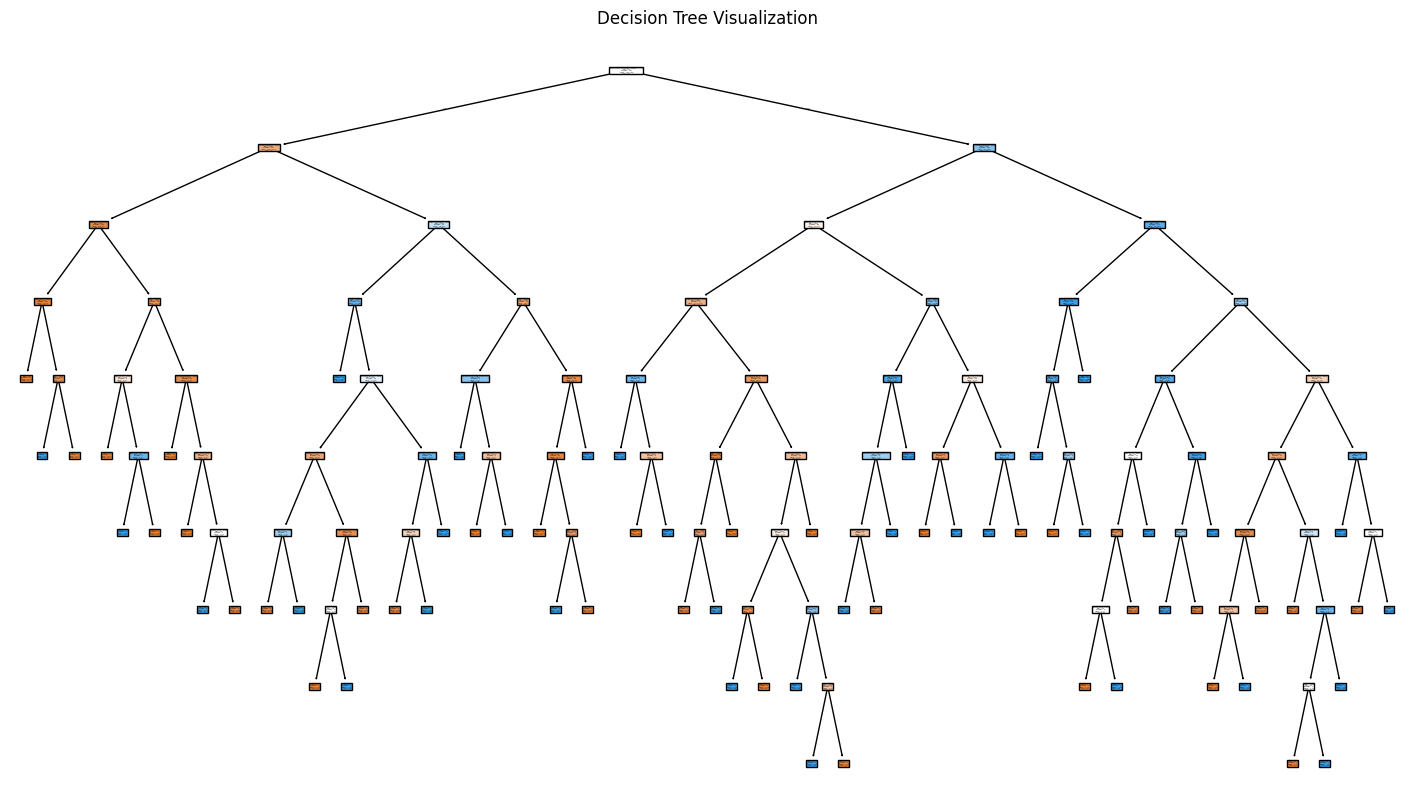

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

model = DecisionTreeClassifier(criterion="gini", random_state=42)
model.fit(X, y)

plt.figure(figsize=(18,10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=["No", "Yes"])
plt.title("Decision Tree Visualization")
plt.show()